<a href="https://colab.research.google.com/github/rickyzhang82/Colab-Collections/blob/master/fine_tuning_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine Tune Your First Model in 30 Minutes

**All Things Open RTP Meetup, live walkthrough**

We are going to take a small open model, Gemma 2 (2B), and teach it to sort customer
support messages into the right category. We will do it on a free Colab T4 GPU, start
to finish, in about fifteen minutes of runtime.

Here is the plan for the next few cells:

1. Install the tools and load the model.
2. Look at real support tickets and shape them into training examples.
3. Test the model **before** we train it, so we have something to compare against.
4. Fine tune it with QLoRA (we only train a tiny adapter, not the whole model).
5. Test it again and watch the accuracy jump.
6. Save the result and, if you want, export it to run on your own laptop.

> One thing before you run: go to Runtime, then Change runtime type, and pick **T4 GPU**.
> Then Runtime, then Run all. That is it.

## 1. Install the tools

This installs Unsloth, which makes fine tuning fast and memory friendly, along with the
Hugging Face training libraries. The versions here are pinned on purpose. Newer versions
of Transformers currently break 4 bit Gemma, so we hold everything at a combination that
is known to work. This cell takes about a minute.

In [ ]:
# This mirrors Unsloth's official Colab install, with versions pinned so the
# notebook behaves the same today as it will on demo day.
%pip install -q sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
%pip install -q --no-deps "unsloth==2026.9.2" "unsloth_zoo==2026.9.1" bitsandbytes accelerate xformers peft trl triton
%pip install -q --no-deps --upgrade "torchao>=0.16.0"
%pip install -q "transformers==4.56.2"
%pip install -q --no-deps "trl==0.22.2"

print("All packages installed. You are ready to go.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.6/992.6 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 104.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/

## 2. Load the model

### What we are fine tuning

We are using **Gemma 2 (2B)**, an open model from Google DeepMind. It comes from the same
research line as Google's Gemini models, but it is small enough to run on a free GPU, and
the weights are openly available so we can actually train on them.

A few numbers that put it in context:

- **About 2.6 billion parameters.** That is small as language models go today, but still
  very capable. It is the kind of size you can realistically host yourself.
- **26 transformer layers**, a model width of 2304, and grouped query attention, which is a
  memory saving trick for the attention step.
- **An 8192 token context window**, far more than we need for short support messages.
- **Trained on roughly 2 trillion tokens** of web text, code, and scientific writing. The
  2B model was trained using knowledge distillation, meaning a larger Gemma model acted as
  a teacher, which is part of why such a small model performs so well.
- A **256 thousand entry vocabulary**, so it handles many languages and symbols.

The exact model we load is `unsloth/gemma-2-2b-it-bnb-4bit`. The `it` means it is the
**instruction tuned** version, already taught to follow instructions and hold a
conversation, so it starts from a sensible place. The `bnb-4bit` part is explained next.

### Why the 4 bit version

Storing 2.6 billion parameters at full precision would take a lot of memory. We instead
load a version that is already compressed to **4 bits per weight**, which shrinks the
memory footprint by roughly four times and lets the whole thing fit comfortably on a free
T4 with room to spare for training.

One thing to expect: the cell below prints a parameter count, and it will look smaller than
2.6 billion. That is because the 4 bit weights are packed tightly together, so the raw
tensor count reads lower. It is the same model, just stored in a more compact form. We also
keep the sequence length at 512 tokens, which is plenty for short support messages and
keeps everything fast during a live demo.

In [ ]:
import torch
from unsloth import FastLanguageModel

MODEL_NAME = "unsloth/gemma-2-2b-it-bnb-4bit"
MAX_SEQ_LENGTH = 512

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,            # let Unsloth pick the right type for the GPU
    load_in_4bit = True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
total_params = sum(p.numel() for p in model.parameters())
gpu_mem = torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else 0

print("=" * 60)
print(f"Model:            {MODEL_NAME}")
print(f"Total parameters: {total_params/1e9:.2f} billion")
print(f"GPU memory used:  {gpu_mem:.2f} GB")
print("=" * 60)
print(f"Model loaded and running on {device}.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.2: Fast Gemma2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Model:            unsloth/gemma-2-2b-it-bnb-4bit
Total parameters: 1.60 billion
GPU memory used:  2.25 GB
Model loaded and running on cuda.


## 3. Look at the data

### Where this comes from

We are using the **Bitext Customer Support dataset**, published by Bitext Innovations on
Hugging Face. You can find it here:
[huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset).
It is released under the CDLA Sharing 1.0 license, which is a permissive community data
license, so it is a safe choice for a public demo like this one.

### What it is

It holds about 27 thousand English customer support requests (26,872 to be exact), and
every request is already labeled. The data is hybrid synthetic. Bitext started from real
support text, pulled out patterns, and used language generation to expand those into many
natural variations, including polite phrasings, casual phrasings, and even typos. That
messiness is a feature, because it looks like what real customers actually write. It was
built specifically to fine tune assistants for customer service.

Each row has a few fields. We only need the first two:

- **instruction**: the customer's message, for example "I want to cancel my order"
- **category**: the high level label we are predicting, for example ORDER or REFUND
- **intent**: a finer grained label (there are 27 of these)
- **response**: a sample answer an agent might give
- **flags**: tags describing the linguistic variations in the message

We classify by **category**, not intent, to keep the demo clear on a projector. The
categories are written in capital letters. We read the exact list straight from the data
rather than hard coding it, so the notebook stays correct even if the dataset is updated.
Let us load it and see what we are working with.

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")
df = dataset.to_pandas()

print(f"Total messages: {len(df):,}\n")

print("A few examples, message on the left and its category on the right:")
print("-" * 70)
for _, row in df[["instruction", "category"]].head(5).iterrows():
    msg = row["instruction"][:60] + ("..." if len(row["instruction"]) > 60 else "")
    print(f"  {row['category']:<14} {msg}")

print("\nHow many messages fall into each category:")
print("-" * 70)
print(df["category"].value_counts())

CATEGORIES = sorted(df["category"].unique().tolist())
print(f"\nThe {len(CATEGORIES)} categories we will classify into:")
print("  " + ", ".join(CATEGORIES))

README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Total messages: 26,872

A few examples, message on the left and its category on the right:
----------------------------------------------------------------------
  ORDER          question about cancelling order {{Order Number}}
  ORDER          i have a question about cancelling oorder {{Order Number}}
  ORDER          i need help cancelling puchase {{Order Number}}
  ORDER          I need to cancel purchase {{Order Number}}
  ORDER          I cannot afford this order, cancel purchase {{Order Number}}

How many messages fall into each category:
----------------------------------------------------------------------
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
CONTACT         1999
INVOICE         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

The 11 categories we will classify into:
  ACCOUNT, CANCEL, CONTACT, DELIVERY, FEEDBACK, INVOICE, ORDER, PAYMEN

## 4. Shape the data into training examples

A model does not learn from a spreadsheet. It learns from text. So we turn each row into a
short prompt that states the task, gives the message, and then gives the correct answer.
That final answer is what the model learns to produce on its own.

We do not need all 27 thousand messages. A small, balanced sample teaches the pattern just
fine and keeps training quick. We take 1000 messages for training and 500 to test with,
and we keep the mix of categories even across both. The seed is fixed at 42 so you get the
same split every time you run this.

In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

SEED = 42
CATEGORY_LIST = ", ".join(CATEGORIES)
EOS = tokenizer.eos_token

# Balanced split: 1000 to train on, 500 held back to test on, categories kept even.
train_df, rest_df = train_test_split(df, train_size=1000, stratify=df["category"], random_state=SEED)
eval_df, _        = train_test_split(rest_df, train_size=500, stratify=rest_df["category"], random_state=SEED)

# The template. During training the answer is filled in. During testing we leave it blank
# and let the model write it. Keeping this format identical in both places matters a lot.
PROMPT = """### Instruction:
Classify the following customer support message into one of these categories: {categories}

### Input:
{message}

### Response:
{category}"""

def format_example(message, category):
    return PROMPT.format(categories=CATEGORY_LIST, message=message, category=category)

# The EOS token is the model's full stop. Without it the model never learns to stop talking.
train_df = train_df.copy()
train_df["text"] = train_df.apply(lambda r: format_example(r["instruction"], r["category"]) + EOS, axis=1)
train_dataset = Dataset.from_pandas(train_df[["text"]], preserve_index=False)

print("Here is one complete training example, exactly as the model sees it:")
print("=" * 70)
print(train_df["text"].iloc[0])
print("=" * 70)
print(f"\nTraining messages: {len(train_df)}")
print(f"Test messages:     {len(eval_df)}")

Here is one complete training example, exactly as the model sees it:
### Instruction:
Classify the following customer support message into one of these categories: ACCOUNT, CANCEL, CONTACT, DELIVERY, FEEDBACK, INVOICE, ORDER, PAYMENT, REFUND, SHIPPING, SUBSCRIPTION

### Input:
is it possible to place na order from {{Delivery Country}}

### Response:
DELIVERY<eos>

Training messages: 1000
Test messages:     500


## 5. Test the model before we train it

This is the honest baseline. The model has strong general language skills, so it will get
some of these right on its own. But watch two things. First, it often picks the wrong
category when two are close, for example SHIPPING versus DELIVERY, or CANCEL versus ORDER.
Second, it likes to explain itself and ramble, when all we want is a single clean label.

We test on fifteen messages the model will never see during training, and we keep the
score so we can compare later.

In [ ]:
FastLanguageModel.for_inference(model)   # switch the model into fast generation mode

test_sample = eval_df.sample(n=15, random_state=SEED).reset_index(drop=True)

def build_prompt(message):
    # Same template as training, ending right after "### Response:" with the newline kept.
    return PROMPT.format(categories=CATEGORY_LIST, message=message, category="")

def classify(message):
    prompt = build_prompt(message)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(**inputs, max_new_tokens=20, do_sample=False,
                            use_cache=True, pad_token_id=tokenizer.eos_token_id)
    raw = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    # Pull out the category name even if the model wrapped it in extra words.
    lower = raw.lower()
    pred = next((c for c in CATEGORIES if c.lower() in lower), (raw.split("\n")[0][:30] or "(none)"))
    return pred, raw

before = [classify(m) for m in test_sample["instruction"]]
before_acc = sum(p == t for (p, _), t in zip(before, test_sample["category"])) / len(test_sample)

print("A few predictions from the untrained model. Notice the rambling:\n")
for i in range(4):
    msg = test_sample["instruction"].iloc[i][:55]
    print(f"  message : {msg}")
    print(f"  model   : {before[i][1][:70]!r}")
    print(f"  correct : {test_sample['category'].iloc[i]}\n")

print("=" * 60)
print(f"Baseline accuracy before fine tuning: {before_acc*100:.0f}%")
print("=" * 60)

A few predictions from the untrained model. Notice the rambling:

  message : want help looking for the fucking bill from {{Person Na
  model   : 'PAYMENT \n\n\n**Explanation:**\n\nThe customer is asking for a bill, which '
  correct : INVOICE

  message : what do i need to do to cancel order {{Order Number}}
  model   : 'CANCEL'
  correct : ORDER

  message : i dont know what i have to do to switch to the {{Accoun
  model   : 'SUBSCRIPTION \n\n\n**Explanation:**\n\nThe message clearly indicates a desi'
  correct : ACCOUNT

  message : shipments to {{Delivery City}}
  model   : 'DELIVERY'
  correct : DELIVERY

Baseline accuracy before fine tuning: 53%


## 6. Add the LoRA adapter

Here is the trick that makes this cheap. Instead of updating all two billion parameters, we
freeze the whole model and bolt on a small set of new weights called a LoRA adapter. We
train only those. It is a bit like adding a thin layer of notes on top of a textbook rather
than rewriting the book. As you will see, we end up training only around one percent of the
model, which is why this fits on a free GPU.

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = SEED,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("=" * 60)
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")
print(f"We are training just {100*trainable/total:.2f}% of the model.")
print("=" * 60)
print("Everything else stays frozen. That is what keeps memory low.")

Unsloth 2026.9.2 patched 26 layers with 26 QKV layers, 26 O layers and 26 MLP layers.


Trainable parameters: 20,766,720
Total parameters:     1,622,970,624
We are training just 1.28% of the model.
Everything else stays frozen. That is what keeps memory low.


## 7. Train

Now we run the training. The number to watch is the loss, printed every ten steps. Loss is
roughly how wrong the model is, so we want it to fall. It starts high, drops fast in the
first few steps as the model figures out the format, and then keeps easing down as it
sharpens up. A hundred steps is enough to make the point and takes about four minutes on a
T4.

In [ ]:
%%time
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    processing_class = tokenizer,
    train_dataset = train_dataset,
    args = SFTConfig(
        dataset_text_field = "text",
        max_length = MAX_SEQ_LENGTH,
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        max_steps = 100,
        learning_rate = 2e-4,
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = SEED,
        output_dir = "outputs",
        report_to = "none",
    ),
)

train_stats = trainer.train()

print("\n" + "=" * 60)
print(f"Training time: {train_stats.metrics['train_runtime']:.0f} seconds")
print(f"Final loss:    {train_stats.metrics['train_loss']:.3f}")
print("=" * 60)
print("Done. Now let us see whether it actually learned anything.")

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 2 | Total steps = 100
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 20,766,720 of 2,635,108,608 (0.79% trained)


Step,Training Loss
10,2.533800
20,0.740800
30,0.482100
40,0.421900
50,0.382000
60,0.369600
70,0.318500
80,0.309500
90,0.298400
100,0.294900



Training time: 335 seconds
Final loss:    0.615
Done. Now let us see whether it actually learned anything.
CPU times: user 3min 50s, sys: 3.93 s, total: 3min 53s
Wall time: 5min 44s


## 8. Look at the loss curve

Numbers scrolling by are hard to read from the back of a room, so here is the same story as
a picture. Each point is the loss at that step. The steep drop at the start is the model
learning the shape of the task. The long gentle tail is it getting more confident.

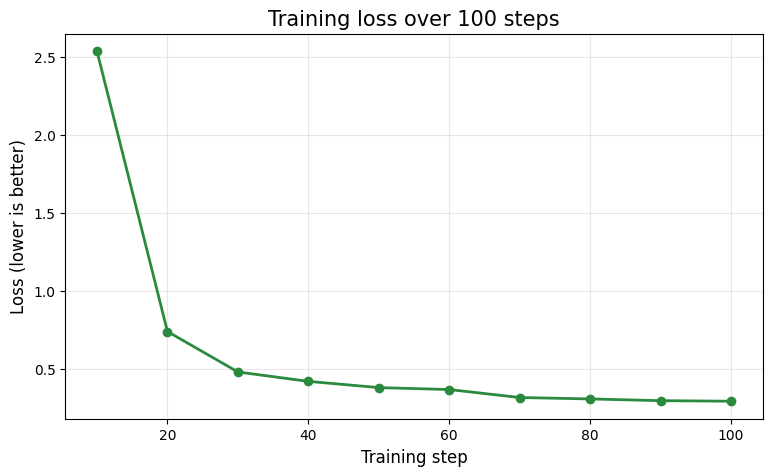

In [ ]:
import matplotlib.pyplot as plt

history = [(h["step"], h["loss"]) for h in trainer.state.log_history if "loss" in h]
steps, losses = zip(*history)

plt.figure(figsize=(9, 5))
plt.plot(steps, losses, marker="o", linewidth=2, color="#2b8a3e")
plt.title("Training loss over 100 steps", fontsize=15)
plt.xlabel("Training step", fontsize=12)
plt.ylabel("Loss (lower is better)", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## 9. Test it again, now that it is trained

Same fifteen messages, same test, but now the model has learned from our data. Two things
should stand out. The answers are clean single labels with no rambling, and the tricky
category boundaries that tripped it up before are mostly fixed. The table below puts the
before and after side by side so you can see exactly what changed.

In [ ]:
FastLanguageModel.for_inference(model)

after = [classify(m) for m in test_sample["instruction"]]
after_acc = sum(p == t for (p, _), t in zip(after, test_sample["category"])) / len(test_sample)

print(f"{'message':<42} {'before':<12} {'after':<12} {'correct':<12}")
print("=" * 82)
for i in range(len(test_sample)):
    msg = test_sample["instruction"].iloc[i][:40]
    true = test_sample["category"].iloc[i]
    b_pred, a_pred = before[i][0], after[i][0]
    flag = "ok" if a_pred == true else "x"
    print(f"{msg:<42} {b_pred:<12} {a_pred:<12} {true:<12} {flag}")

print("=" * 82)
print(f"Before fine tuning: {before_acc*100:.0f}%    After fine tuning: {after_acc*100:.0f}%")

message                                    before       after        correct     
want help looking for the fucking bill f   PAYMENT      INVOICE      INVOICE      ok
what do i need to do to cancel order {{O   CANCEL       ORDER        ORDER        ok
i dont know what i have to do to switch    ACCOUNT      ACCOUNT      ACCOUNT      ok
shipments to {{Delivery City}}             DELIVERY     DELIVERY     DELIVERY     ok
troubles setting my secondary shipping a   DELIVERY     SHIPPING     SHIPPING     ok
chnaging order {{Order Number}}            ORDER        ORDER        ORDER        ok
I have  to locate my bill #00108, help m   FEEDBACK     INVOICE      INVOICE      ok
new pro account                            ACCOUNT      ACCOUNT      ACCOUNT      ok
I cannot subscribeto the corporate newsl   SUBSCRIPTION SUBSCRIPTION SUBSCRIPTION ok
i dont know how i can cancel purchase {{   CANCEL       ORDER        ORDER        ok
do you ship to {{Delivery City}}?          SHIPPING     DELIVERY    

## 10. Before and after at a glance

One picture to sum it up. A small adapter, a thousand examples, and a few minutes of
training moved the model from guessing to reliable. With more data and more steps, teams
routinely push this into the high nineties.

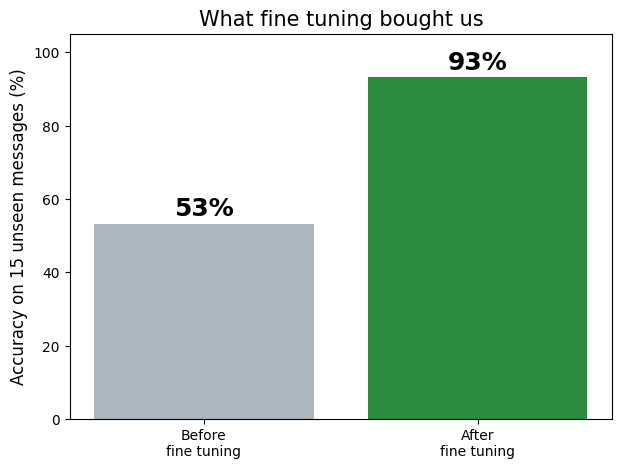

In [ ]:
plt.figure(figsize=(7, 5))
bars = plt.bar(["Before\nfine tuning", "After\nfine tuning"],
               [before_acc*100, after_acc*100],
               color=["#adb5bd", "#2b8a3e"])
plt.ylabel("Accuracy on 15 unseen messages (%)", fontsize=12)
plt.ylim(0, 105)
plt.title("What fine tuning bought us", fontsize=15)
for bar, acc in zip(bars, [before_acc, after_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, acc*100 + 2, f"{acc*100:.0f}%",
             ha="center", fontsize=18, fontweight="bold")
plt.show()

## 11. Save the adapter

The fine tuned part is just the adapter, and it is small compared to the full model. The
base model is around 5 GB. The adapter is a fraction of that, so this is the only piece you
need to store, version, or share with a teammate. They load the same base model and drop
your adapter on top.

In [ ]:
import os, glob

ADAPTER_DIR = "fine-tuned-support-ticket-classifier"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

adapter_mb = sum(os.path.getsize(f) for f in glob.glob(os.path.join(ADAPTER_DIR, "adapter_model.*"))) / 1e6

print(f"Saved to: {ADAPTER_DIR}/")
print(f"Adapter weights: {adapter_mb:.0f} MB, versus about 5 GB for the full base model.\n")
print("This adapter is easy to:")
print("  - keep in Git next to your code")
print("  - serve alongside the base model with a tool like vLLM or Ollama")
print("  - retrain whenever your categories or your data change")
print("  - hand to a teammate as one small file")

Saved to: fine-tuned-support-ticket-classifier/
Adapter weights: 83 MB, versus about 5 GB for the full base model.

This adapter is easy to:
  - keep in Git next to your code
  - serve alongside the base model with a tool like vLLM or Ollama
  - retrain whenever your categories or your data change
  - hand to a teammate as one small file


## 12. Export to GGUF so you can run it anywhere

Everything so far lives on a cloud GPU. GGUF is a single file format that lets you run this
same model on your own laptop, with no GPU and no cloud, using tools like Ollama or
llama.cpp. Under the hood this merges the adapter back into the model, converts it, and
compresses it to 4 bit so it stays small and fast on a normal machine.

Heads up for the live demo: this step compiles a converter the first time and can take ten
minutes or more, so you will usually run it after the talk rather than on stage. The next
cell does the export and then shows you the file it produced.

In [ ]:
model.save_pretrained_gguf("gemma-support-classifier", tokenizer, quantization_method="q4_k_m")

# Unsloth writes the .gguf and a ready made Ollama Modelfile into a sibling folder
# named "<name>_gguf". Let us show exactly what landed there.
import os
GGUF_DIR = "gemma-support-classifier_gguf"
print("\nFiles produced:")
for f in sorted(os.listdir(GGUF_DIR)):
    path = os.path.join(GGUF_DIR, f)
    size_mb = os.path.getsize(path) / 1e6
    marker = "  <-- this is your model" if f.endswith(".gguf") else ""
    print(f"  {size_mb:8.1f} MB  {f}{marker}")

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/913 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/5.23G [00:00<?, ?B/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [02:11<00:00, 131.41s/it]


Unsloth: Merge process complete. Saved to `/content/gemma-support-classifier`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b10840-mix-d5c17a0 (app-b10840-mix-d5c17a0-linux-x64-cpu.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['gemma-support-classifier_gguf/gemma-2-2b-it.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...


Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.


Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['gemma-support-classifier_gguf/gemma-2-2b-it.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model gemma-support-classifier_gguf/gemma-2-2b-it.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to gemma-support-classifier_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f gemma-support-classifier_gguf/Modelfile

Files produced:
       0.0 MB  Modelfile
    1708.6 MB  gemma-2-2b-it.Q4_K_M.gguf  <-- this is your model


## 13. Run it on your own machine

Once you have the `.gguf` file, here is how to actually use it locally. The export in the
previous cell created `gemma-support-classifier_gguf/gemma-2-2b-it.Q4_K_M.gguf`. First
download that file out of Colab:

```python
from google.colab import files
files.download("gemma-support-classifier_gguf/gemma-2-2b-it.Q4_K_M.gguf")
```

### Option A: Ollama (the easy path)

Install Ollama from [ollama.com](https://ollama.com). Put the `.gguf` file in a folder next
to a file called `Modelfile` with the content below. This template matches how we trained
the model, so it answers with a clean category. (Unsloth also drops a generic `Modelfile`
into the `_gguf` folder, but this one is tuned for our classification format.)

```
FROM ./gemma-2-2b-it.Q4_K_M.gguf

TEMPLATE """### Instruction:
Classify the following customer support message into one of these categories: ACCOUNT, CANCEL, CONTACT, DELIVERY, FEEDBACK, INVOICE, ORDER, PAYMENT, REFUND, SHIPPING, SUBSCRIPTION

### Input:
{{ .Prompt }}

### Response:
"""

PARAMETER stop "<eos>"
PARAMETER temperature 0
```

Then build it and ask it something:

```bash
ollama create support-classifier -f Modelfile
ollama run support-classifier "where is my package, it has been two weeks"
```

You should get back a single category like `DELIVERY`, running entirely on your own machine.

### Option B: llama.cpp (the direct path)

If you use [llama.cpp](https://github.com/ggerganov/llama.cpp) instead, point it at the same
file and pass the same prompt format:

```bash
./llama-cli -m gemma-2-2b-it.Q4_K_M.gguf -n 20 -p "### Instruction:
Classify the following customer support message into one of these categories: ACCOUNT, CANCEL, CONTACT, DELIVERY, FEEDBACK, INVOICE, ORDER, PAYMENT, REFUND, SHIPPING, SUBSCRIPTION

### Input:
I was double charged for my subscription

### Response:
"
```

No API keys, no cloud, no per request cost. The model is yours.

## That is the whole loop

In about fifteen minutes, on free hardware, we:

1. Loaded a 2B model compressed to 4 bit.
2. Turned real support tickets into training examples.
3. Measured the model cold, before any training.
4. Fine tuned a small adapter with QLoRA, training around one percent of the model.
5. Watched accuracy climb and the answers get clean.
6. Saved a small adapter and exported a file you can run at home.

That is fine tuning. Not a research project, not a data center, just a focused dataset and a
few minutes on a free GPU.

**Tools we used**
- [Unsloth](https://github.com/unslothai/unsloth) for fast, memory friendly training
- [Hugging Face TRL](https://github.com/huggingface/trl) and [Datasets](https://huggingface.co/docs/datasets)
- [Bitext customer support dataset](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset), CDLA Sharing 1.0

> This notebook is yours. Point it at your own data and see what it learns.